In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [2]:
# Load datasets as pandas dataframes

df = pd.read_csv('data/train.csv')
X_kaggle = pd.read_csv('data/test.csv')

In [3]:
df.shape

(891, 12)

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Split the dataset into features (X) and labels (y)

y = df['Survived'].copy()
X = df.drop(columns=['Survived']).copy()

In [6]:
X.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Preprocessing

In [7]:
# Plot countplots for categorical features to show survival distribution

def countplot(tmp_df):
    categorical_cols = tmp_df.select_dtypes(include=['object', 'category']).columns.tolist()
    num_plots = len(categorical_cols)
    fig, axes = plt.subplots(nrows=1, ncols=num_plots, figsize=(6 * num_plots, 5))

    for i, col in enumerate(categorical_cols):
        sns.countplot(x=col, hue='Survived', data=tmp_df, ax=axes[i], palette='Set2')
        axes[i].set_title(f'Survival Rate by {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

In [8]:
# Plot heatmap of the correlation matrix for numeric features

def correlation_plot(tmp_df):
    plt.figure(figsize=(7, 5))
    sns.heatmap(tmp_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.show()

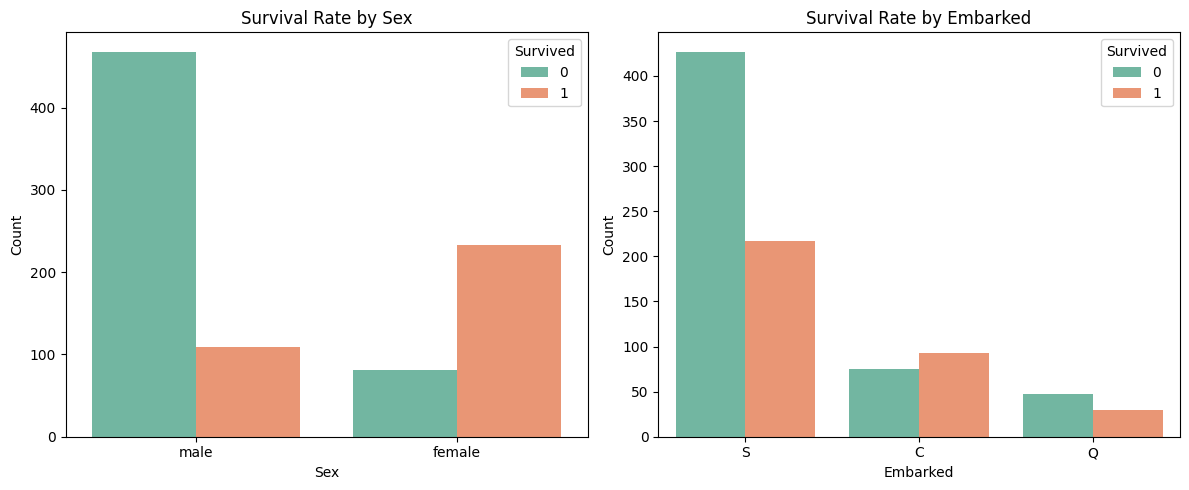

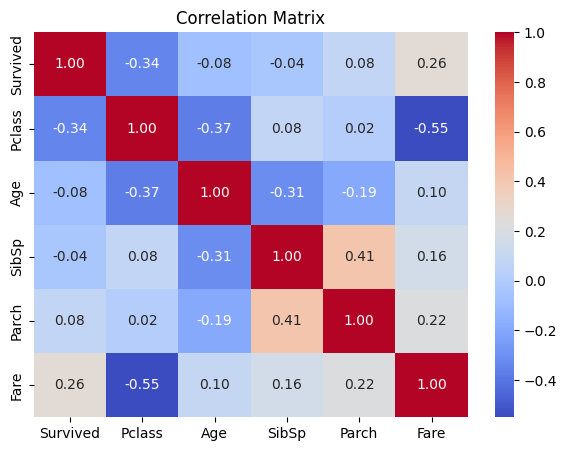

In [9]:
# Drop irrelevant columns from the dataframe 
# before plotting the countplots and the correlation matrix

tmp_df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

countplot(tmp_df)
correlation_plot(tmp_df)

In [10]:
# Delete columns that are not used or have too many nulls

X = X.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Age', 'SibSp', 'Parch', 'Embarked'])

In [11]:
X.head()

,Pclass,Sex,Fare
0,3,male,7.2500
1,1,female,71.2833
2,3,female,7.9250
3,1,female,53.1000
4,3,male,8.0500


In [12]:
# Encode categorical columns using One-Hot Encoding

X = pd.get_dummies(X, columns=['Sex'], drop_first=True, dtype=int)

In [13]:
X.head()

,Pclass,Fare,Sex_male
0,3,7.2500,1
1,1,71.2833,0
2,3,7.9250,0
3,1,53.1000,0
4,3,8.0500,1


In [14]:
# Split to train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [15]:
X_train.shape

(668, 3)

In [16]:
X_test.shape

(223, 3)

In [17]:
# Normalize data using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [18]:
class LR:
    def __init__(self, learning_rate, epochs):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    # Apply the sigmoid activation function
    def sigmoid(self, z):
        return 1.0 / (1 + np.exp(-z))
    
    # Compute binary cross-entropy loss of all layers
    def cal_loss(self, y_true, y_pred):
        # Use epsilon to avoid log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1- epsilon)

        return -np.mean((y_true * np.log(y_pred)) + ((1 - y_true) * np.log(1 - y_pred)))
    
    # Learning phase of the model and fit the model to the training data
    def fit(self, X, y):
        # Initialization weights and bias
        self.weights = np.zeros(X.shape[1])
        self.bias = 0.0

        for e in range(self.epochs):
            # Linear combination of the weights and the bias
            z = np.dot(X, self.weights) + self.bias
            # Predict the labels by using sigmoid activation function
            y_pred = self.sigmoid(z)

            # Compute gradients of the weights and the bias
            dw = (1 / X.shape[0]) * np.dot(X.T, (y_pred - y))
            db = (1 / X.shape[0]) * np.sum(y_pred - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute the loss and store it for plotting
            loss = self.cal_loss(y, y_pred)
            self.loss_history.append(loss)

            if e % 100 == 0 or e == self.epochs - 1:
                print(f"Epoch {e}: Loss = {loss:.4f}")

    # Compute the prediction probability by linear combination and sigmoid
    def predict_prob(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    # Specify the labels by threshold and prediction probability
    def predict(self, X, thresh=0.5):
        return [1 if i > thresh else 0 for i in self.predict_prob(X)]

In [19]:
# Train the logistic regression model on the training data

lr_model = LR(learning_rate=0.045, epochs=1000)
lr_model.fit(X_train, y_train)

Epoch 0: Loss = 0.6931
Epoch 100: Loss = 0.5017
Epoch 200: Loss = 0.4777
Epoch 300: Loss = 0.4721
Epoch 400: Loss = 0.4704
Epoch 500: Loss = 0.4696
Epoch 600: Loss = 0.4693
Epoch 700: Loss = 0.4692
Epoch 800: Loss = 0.4691
Epoch 900: Loss = 0.4690
Epoch 999: Loss = 0.4690


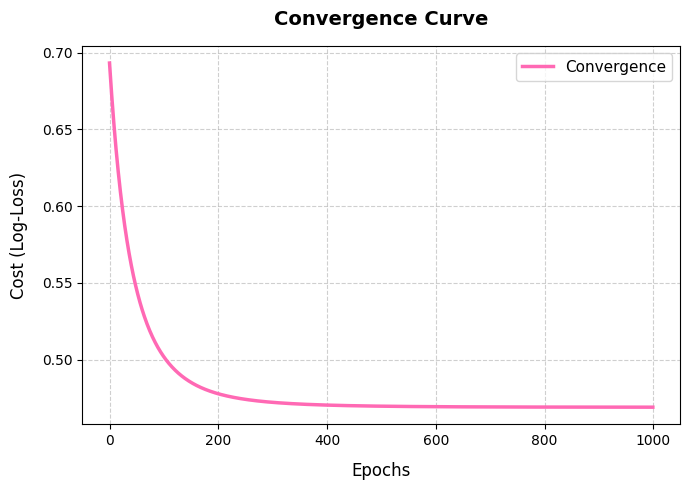

In [20]:
# Plot convergence curve by loss values

plt.figure(figsize=(7, 5))

plt.plot(lr_model.loss_history, color='hotpink', linewidth=2.5, label='Convergence')

plt.title('Convergence Curve', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12, labelpad=10)
plt.ylabel('Cost (Log-Loss)', fontsize=12, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Predict values using trained model

In [21]:
# Predict the output class for the training and test datasets

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

### evaluation metrics

In [22]:
# Calculate accuracy for the training set

from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

print('On Training Set')
print(f'Accuracy Score: {accuracy_score(y_train, y_train_pred):.3f}')

On Training Set
Accuracy Score: 0.786


In [23]:
# Calculate all metrics for the testing set

print('On Test Set')
print(f'Accuracy Score: {accuracy_score(y_test, y_test_pred):.3f}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_test_pred)}')
print(f'Recall Score: {recall_score(y_test, y_test_pred):.3f}')
print(f'Precision Score: {precision_score(y_test, y_test_pred):.3f}')
print(f'F1 Score: {f1_score(y_test, y_test_pred):.3f}')

On Test Set
Accuracy Score: 0.771
Confusion Matrix:
 [[109  25]
 [ 26  63]]
Recall Score: 0.708
Precision Score: 0.716
F1 Score: 0.712


## Prepare test data for kaggle

In [ ]:
# Store Passenger Ids for submission file

passenger_ids = X_kaggle['PassengerId']

In [ ]:
X_kaggle.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64